# 4 文本数据分析

## 学习目标
- 了解文本数据分析的作用。
- 掌握常用的几种文本数据分析方法。

## 1 文件数据分析介绍
- 文本数据分析的作用：
  - 文本数据分析能够有效帮助我们理解数据语料，快速检查出语料可能存在的问题，并指导之后模型训练过程中一些超参数的选择。
- 常用的几种文本数据分析方法：
  - 标签数量分布
  - 句子长度分布
  - 词频统计与关键词词云

# 2 数据集说明

- 我们将基于真实的中文酒店评论语料来讲解常用的几种文本数据分析方法。
- 中文酒店评论语料：
  - 属于二分类的中文情感分析语料，该语料存放在 `./cn_data` 目录下。
  - 其中 train.tsv 代表训练集，dev.tsv 代表验证集，二者数据样式相同。
- train.tsv 数据样式：

sentence    label

早餐不好，服务不到位，晚餐无酒量，早餐晚餐相同，房间条件不好，餐厅不分吸烟区，房间不分有无烟区。    0

去的时候，酒店大厅和餐厅在装修，感觉大厅有点挤。由于餐厅装修本来该享受的，也没有享受（他们是有很长时间没有在酒店里住了[补充：原图写“他们是8点有很长时间”，疑为笔误]，以前去北京在这里住的较多。这次住进来发现换了液晶电视，但网络不是很理想，住的还是豪华海景房，打开窗户就可以看见楼栋和海景。记得很早以前也住过，现在重新装修过，房间小了一点，但是干净整洁，很有香气的特色，性价比较高，推荐一下哦！ 1

酒店的装修比较陈旧，房间的隔音，主要是卫生间隔音非常差，只能算是一般的。 0

酒店有点旧，房间比较小，但酒店的位子不错，就在海边，可以直接去游泳。8楼的房间打开窗户就是海。如果位置很好，走到海边，清凉的海风等[补充：原图写“清凉等5分钟都用了”，语义不通，推测为“清凉的海风”或类似]5分钟都用了，周边公交车很多很方便，就是出租车不太发达（老城区路况好，酒店设备一般，客房里卧室的不能上网，要到客厅去。 0

- train.tsv 数据样式说明：
  - train.tsv 中的数据内容共分为 2 列，第一列数据代表具有感情色彩的评论文本；第二列数据，0 或 1，代表每条文本数据是积极还是消极的评论，0 代表消极，1 代表积极。

# 3 获取标签数量分布

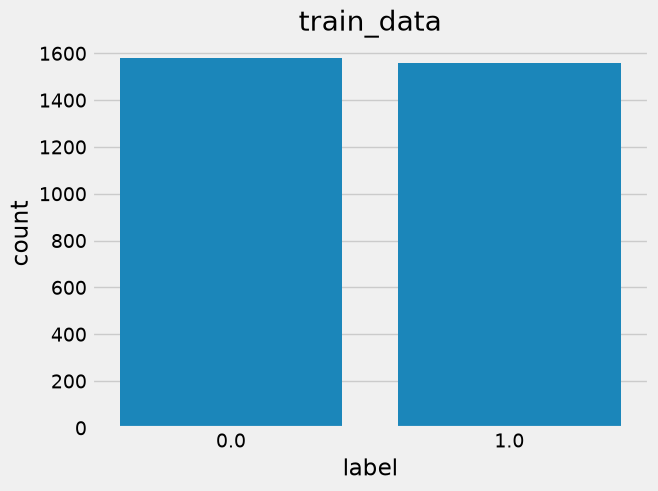

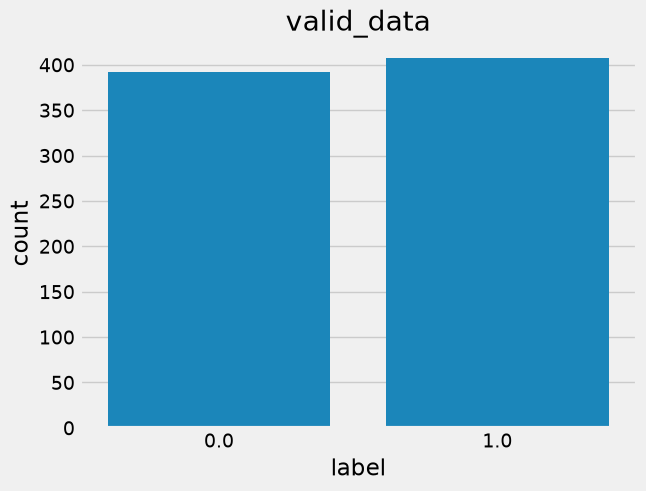

In [6]:
# 导入必备工具包
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 设置显示风格
plt.style.use('fivethirtyeight')

# 分别读取训练tsv和验证tsv
train_data = pd.read_csv("cn_data/train.tsv", sep="\t")
valid_data = pd.read_csv("cn_data/dev.tsv", sep="\t")

# 获得训练数据标签数量分布
sns.countplot(x="label", data=train_data)
plt.title("train_data")
plt.show()

# 获取验证数据标签数量分布
sns.countplot(x="label", data=valid_data)
plt.title("valid_data")
plt.show()

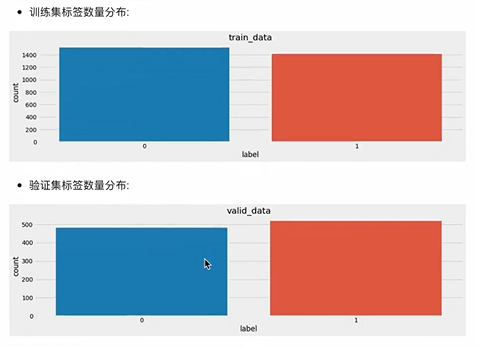

- 分析：
  - 在深度学习模型评估中，我们一般使用ACC作为评估指标，若想将ACC的基线定义在50%左右，则需要我们的正负样本比例维持在1:1左右，否则就要进行必要的数据增强或数据删减。上图中训练和验证集正负样本都稍有不同，可以进行一些数据增强。

# 4 获取句子长度分布

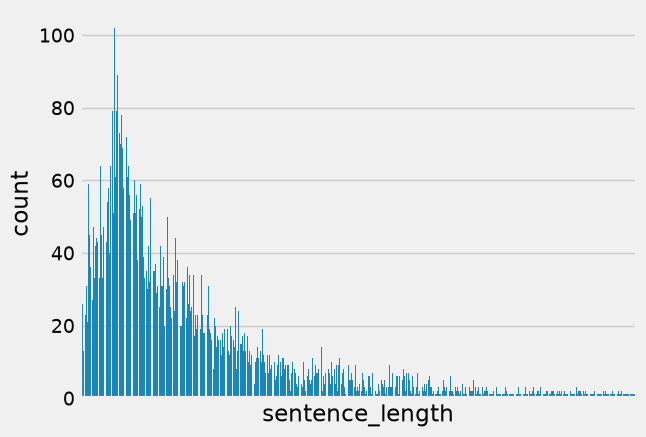

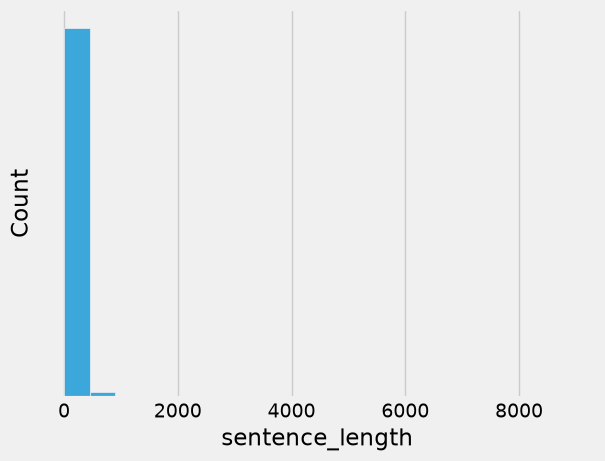

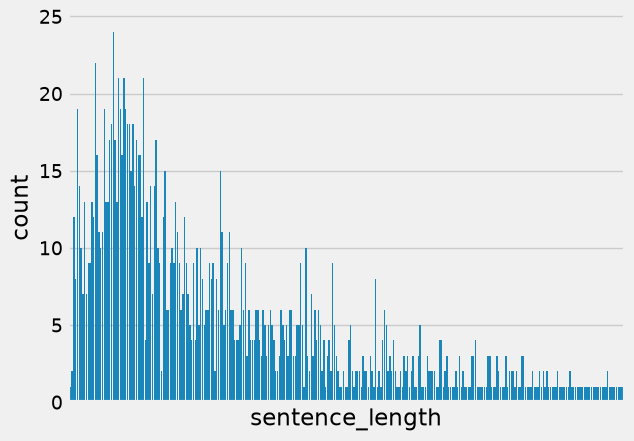

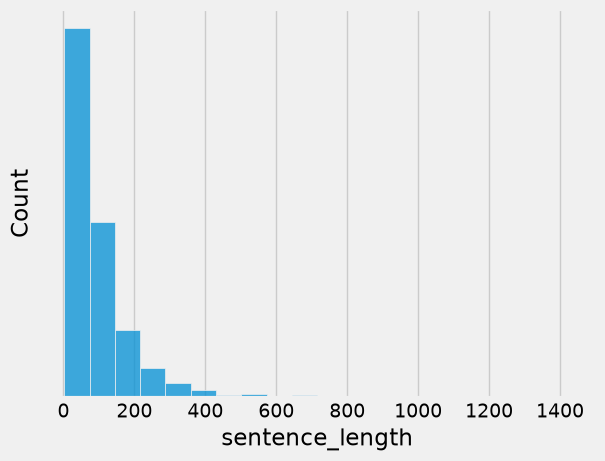

In [7]:
# 在训练数据中添加新的句子长度列，每个元素的值都是对应的句子列的长度
train_data["sentence_length"] = list(map(lambda x: len(x), train_data["sentence"]))

# 绘制句子长度列的数量分布图
sns.countplot(x="sentence_length", data=train_data)
# 主要关注count长度分布的纵坐标，不需要绘制横坐标，横坐标范围通过dist图进行查看
plt.xticks([])
plt.show()

# 绘制dist长度分布图
sns.histplot(train_data["sentence_length"], bins=20)
# 主要关注dist长度分布横坐标，不需要绘制纵坐标
plt.yticks([])
plt.show()

# 在验证数据中添加新的句子长度列，每个元素的值都是对应的句子列的长度
valid_data["sentence_length"] = list(map(lambda x: len(x), valid_data["sentence"]))

# 绘制句子长度列的数量分布图
sns.countplot(x="sentence_length", data=valid_data)
# 主要关注count长度分布的纵坐标，不需要绘制横坐标，横坐标范围通过dist图进行查看
plt.xticks([])
plt.show()

# 绘制dist长度分布图
sns.histplot(valid_data["sentence_length"], bins=20)

# 主要关注dist长度分布横坐标，不需要绘制纵坐标
plt.yticks([])
plt.show()

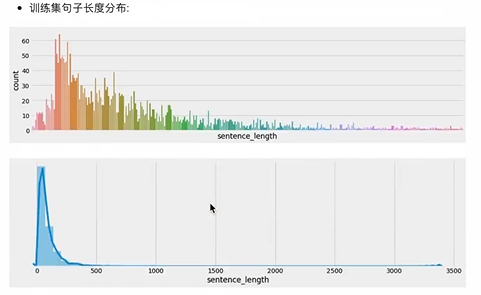

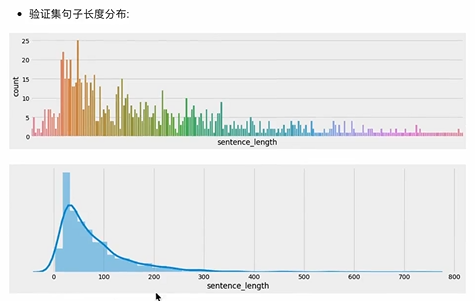

# 5 获取正负样本长度散点分布

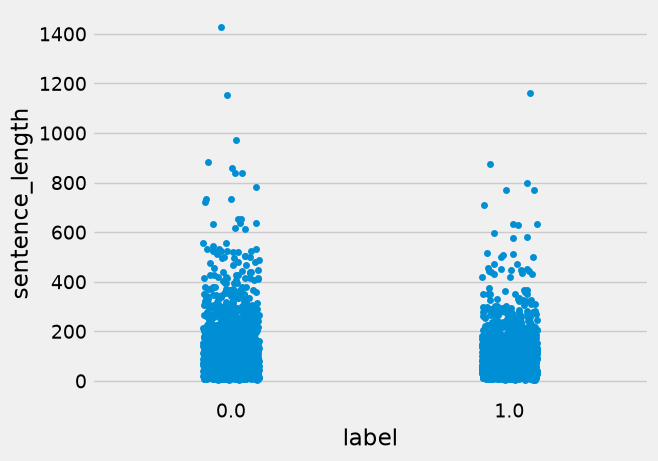

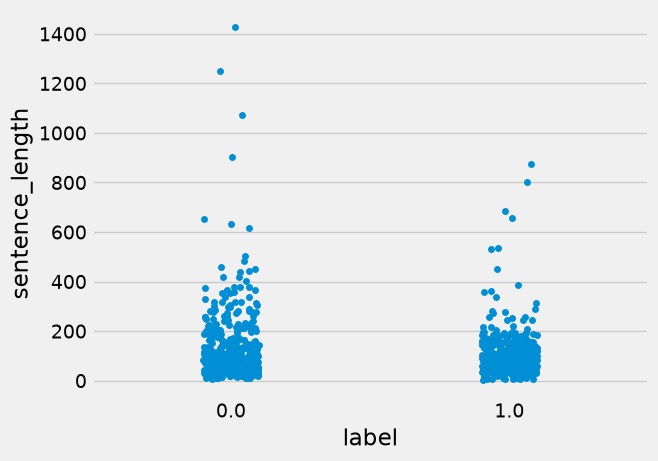

In [8]:
# 导入必备工具包
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 设置显示风格
plt.style.use('fivethirtyeight')

# 分别读取训练tsv和验证tsv
train_data = pd.read_csv("cn_data/train.tsv", sep="\t")
valid_data = pd.read_csv("cn_data/dev.tsv", sep="\t")

# 创建句子长度列
train_data["sentence_length"] = list(map(lambda x: len(x), train_data["sentence"]))
valid_data["sentence_length"] = list(map(lambda x: len(x), valid_data["sentence"]))

# 绘制训练集长度分布的散点图
sns.stripplot(y='sentence_length', x='label', data=train_data)
plt.show()

# 绘制验证集长度分布的散点图
sns.stripplot(y='sentence_length', x='label', data=valid_data)
plt.show()

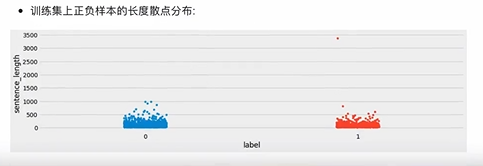

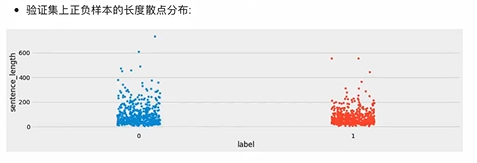

- 分析：
  - 通过查看正负样本长度散点图，可以有效定位异常点的出现位置，帮助我们更准确进行人工语料审查。上图中在训练集正样本中出现了异常点，它的句子长度近3500左右，需要我们人工审查。

In [9]:
# 导入jiebai用于分词
# 导入chain方法用于扁平化列表
import jieba
from itertools import chain

# 进行训练集的句子进行分词，并统计出不同词汇的总数
train_vocab = set(chain(*map(lambda x: jieba.lcut(x), train_data["sentence"])))
print("训练集共包含不同词汇总数为：", len(train_vocab))

# 进行验证集的句子进行分词，并统计出不同词汇的总数
valid_vocab = set(chain(*map(lambda x: jieba.lcut(x), valid_data["sentence"])))
print("训练集共包含不同词汇总数为：", len(valid_vocab))

训练集共包含不同词汇总数为： 5964
训练集共包含不同词汇总数为： 3741


## 6 获取不同词汇总数统计

In [10]:
# 导入jieba用于分词
# 导入chain方法用于扁平化列表
import jieba
from itertools import chain

# 进行训练集的句子进行分词，并统计出不同词汇的总数
train_vocab = set(chain(*map(lambda x: jieba.lcut(x), train_data["sentence"])))
print("训练集共包含不同词汇总数为：", len(train_vocab))

# 进行验证集的句子进行分词，并统计出不同词汇的总数
valid_vocab = set(chain(*map(lambda x: jieba.lcut(x), valid_data["sentence"])))
print("训练集共包含不同词汇总数为：", len(valid_vocab))

训练集共包含不同词汇总数为： 5964
训练集共包含不同词汇总数为： 3741


> - 输出效果：

训练集共包含不同词汇总数为： 12147  
训练集共包含不同词汇总数为： 6857

# 7 小结

- 学习了文本数据分析的作用：
  - 文本数据分析能够有效帮助我们理解数据语料，快速检查出语料可能存在的问题，并指导之后模型训练过程中一些超参数的选择。

- 学习了常用的几种文本数据分析方法：
  - 标签数量分布  
  - 句子长度分布  
  - 词频统计  

- 学习了基于真实的中文酒店评论语料进行几种文本数据分析方法。
  - 获得训练集和验证集的标签数量分布  
  - 获取训练集和验证集的句子长度分布  
  - 获取训练集和验证集的正负样本长度散点分布  
  - 获得训练集与验证集不同词汇总数统计